In [33]:
import pandas as pd


In [34]:
%run analysis_utils.py

In [35]:
results_mean = pd.read_csv('/home/haitham/scFM_eval/results/embedding_bootstrap/embedding.metrics.mean.csv', index_col=1)
results_std = pd.read_csv('/home/haitham/scFM_eval/results/embedding_bootstrap/embedding.metrics.std.csv', index_col=1)
results_10_runs = pd.read_csv('~/scFM_eval/results/embedding_bootstrap/embedding.metrics.bootstrap.csv', index_col=2)


In [36]:
results_10_runs

,run,model,group,leiden_resolution,n_leiden_clusters,NMI_cluster/label,ARI_cluster/label,ASW_label,graph_conn,ASW_batch,...,PCR_batch,iLISI,cLISI,kBET,avg_bio,knn_label_purity,knn_batch_purity,batch_pred_acc,kNN_label_acc,kNN_label_f1_macro
model_display,,,,,,,,,,,,,,,,,,,,,
HVG,0,hvg_seurat_4096,Baseline,0.2,14,0.739425,0.684419,0.517525,0.983183,0.475448,...,0.201333,0.027189,1.0,0.512754,0.647123,0.957867,0.415560,0.3200,0.9245,0.909779
HVG,1,hvg_seurat_4096,Baseline,0.1,10,0.765124,0.728333,0.516845,0.977675,0.476484,...,0.202841,0.026069,1.0,0.413550,0.670101,0.957400,0.414553,0.3195,0.8995,0.907264
HVG,2,hvg_seurat_4096,Baseline,0.1,9,0.734829,0.680352,0.517481,0.981039,0.476495,...,0.200860,0.028659,1.0,0.531328,0.644220,0.956827,0.413713,0.3105,0.9130,0.912007
HVG,3,hvg_seurat_4096,Baseline,0.1,10,0.732584,0.695202,0.517861,0.971821,0.474983,...,0.201534,0.027581,1.0,0.382888,0.648549,0.952220,0.410107,0.2930,0.8990,0.899312
HVG,4,hvg_seurat_4096,Baseline,0.2,12,0.748415,0.697879,0.517153,0.980973,0.473647,...,0.202307,0.029358,1.0,0.509024,0.654482,0.956993,0.413920,0.3180,0.9100,0.898508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Nicheformer,5,nicheformer_nicheformer,Other,0.5,10,0.681396,0.639256,0.508225,0.954339,0.455452,...,0.161206,0.034644,1.0,0.430374,0.609626,0.905427,0.309240,0.4030,0.9270,0.816989
Nicheformer,6,nicheformer_nicheformer,Other,0.3,7,0.641187,0.581740,0.511798,0.946483,0.456517,...,0.161133,0.034782,1.0,0.421150,0.578242,0.896727,0.310773,0.3990,0.9300,0.768839
Nicheformer,7,nicheformer_nicheformer,Other,0.3,7,0.630049,0.571631,0.508663,0.954237,0.455576,...,0.161010,0.034647,1.0,0.419086,0.570114,0.900487,0.313427,0.4100,0.9285,0.744694


In [37]:
results_mean.model.unique()

array(['hvg_seurat_4096', 'state_se600m_epoch16', 'scfoundation',
       'geneformer_V2-104M_CLcancer-i4096', 'geneformer_V2-316M-i4096',
       'continue_geneformer_V1-10M-i2048_continue',
       'geneformer_V1-10M-i2048', 'full_geneformer_V2-104M-i4096',
       'continue_geneformer_V2-104M-i4096_continue',
       'geneformer_V2-104M-i4096', 'scgpt_cancer-i2048',
       'scgpt_human-i2048', 'cellplm_85M-20231027', 'scimilarity_v1.1',
       'pca_n100', 'pca_n50', 'pca_n20', 'scvi', 'scconcept_corpus30m',
       'nicheformer_nicheformer'], dtype=object)

In [52]:
results_mean['model_disp'] = results_mean.model.map(MODEL_NAME_MAP)
results_std['model_disp'] = results_std.model.map(MODEL_NAME_MAP)
results_10_runs['model_disp'] = results_10_runs.model.map(MODEL_NAME_MAP)

results_10_runs=results_10_runs.set_index('model_disp')
results_mean=results_mean.set_index('model_disp')
results_std=results_std.set_index('model_disp')

In [54]:
results_mean.index.unique()

Index(['HVG', 'STATE', 'scFoundation', 'GF-V2 [cancer]', 'GF-V2-Deep',
       'GF-V1 [continue]', 'GF-V1', 'GF-V2 [Full]', 'GF-V2 [continue]',
       'GF-V2', 'scGPT [cancer]', 'scGPT', 'CellPLM', 'SCimiarity',
       'PCA [100]', 'PCA [50]', 'PCA [20]', 'scVI', 'scConcept',
       'Nicheformer'],
      dtype='object', name='model_disp')

In [55]:
import matplotlib.pyplot as plt
import numpy as np


    
import seaborn as sns

def plot_groups(data_df, cols=['ASW_label', 'NMI_cluster/label']):
    assert all(col in data_df.columns for col in cols), "One or more columns not found in data"
    assert 'group' in data_df.columns

    # Use Seaborn color palette for a modern look
    palette = sns.color_palette("Set2", n_colors=len(cols))
    column_colors = {col: palette[i] for i, col in enumerate(cols)}

    fig, ax = plt.subplots(figsize=(14, 6))
    labels = []
    xticks = []
    shift = 0
    gap = 1
    bar_width = 0.8 / len(cols)

    groups = sorted(data_df.group.unique())
    for g in groups:
        subset = data_df[data_df.group == g].copy().sort_values(cols[0])
        num_items = len(subset)

        for i, col in enumerate(cols):
            values = subset[col].values
            x_pos = shift + np.arange(num_items) + i * bar_width
            ax.bar(
                x_pos, values, 
                width=bar_width, 
                label=col if shift == 0 else None, 
                color=column_colors[col],
                edgecolor='white'
            )

            if i == 0:
                labels.extend(subset.index)
                xticks.extend(shift + np.arange(num_items) + (len(cols) / 2 - 0.5) * bar_width)

        shift += num_items + gap

    # Format axes and title
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels, rotation=90, fontsize=16)
    ax.set_ylim(0.2, 0.9)
    ax.legend( frameon=False, loc='upper right', fontsize=12)

    # Remove spines for a clean look
    sns.despine(ax=ax, left=True, right=True, top=True)
    ax.tick_params(axis='y', length=0)

    # ax.set_title("Comparison of Metrics by Group", fontsize=14, weight='bold')
    ax.set_ylabel("Score", fontsize=16)
    plt.tight_layout()
    return fig

In [56]:
# results_mean['group'] = results_mean.index.map(map_groups)

In [57]:
results_mean

,model,group,leiden_resolution,n_leiden_clusters,NMI_cluster/label,ARI_cluster/label,ASW_label,graph_conn,ASW_batch,ASW_label/batch,...,kBET,avg_bio,knn_label_purity,knn_batch_purity,batch_pred_acc,kNN_label_acc,kNN_label_f1_macro,NMI,ARI,ASW
model_disp,,,,,,,,,,,,,,,,,,,,,
HVG,hvg_seurat_4096,Baseline,0.12,10.3,0.740106,0.696863,0.517404,0.978898,0.475378,0.936765,...,0.468333,0.651458,0.955699,0.413727,0.31305,0.91390,0.900994,0.740106,0.696863,0.517404
STATE,state_se600m_epoch16,Other,0.35,14.1,0.685908,0.608709,0.520686,0.978401,0.483744,0.952953,...,0.461541,0.605101,0.916417,0.359021,0.48145,0.96115,0.948579,0.685908,0.608709,0.520686
scFoundation,scfoundation,Other,0.11,9.2,0.782401,0.750558,0.570561,0.978664,0.462518,0.847248,...,0.404652,0.701173,0.956679,0.388183,0.48115,0.96795,0.966797,0.782401,0.750558,0.570561
GF-V2 [cancer],geneformer_V2-104M_CLcancer-i4096,Geneformer,0.19,10.3,0.744745,0.687745,0.506931,0.961113,0.441583,0.815176,...,0.398653,0.646473,0.940879,0.358445,0.44315,0.95765,0.941730,0.744745,0.687745,0.506931
GF-V2-Deep,geneformer_V2-316M-i4096,Geneformer,0.14,10.2,0.764640,0.709695,0.521663,0.969456,0.453251,0.837957,...,0.359361,0.665332,0.951339,0.395468,0.48395,0.96280,0.952569,0.764640,0.709695,0.521663
GF-V1 [continue],continue_geneformer_V1-10M-i2048_continue,Geneformer,0.24,8.1,0.754550,0.720837,0.527523,0.960075,0.442670,0.834298,...,0.441547,0.667637,0.939759,0.289361,0.36230,0.95305,0.900939,0.754550,0.720837,0.527523
GF-V1,geneformer_V1-10M-i2048,Geneformer,0.11,5.2,0.804200,0.840493,0.521204,0.964583,0.444275,0.840833,...,0.451779,0.721966,0.939225,0.279495,0.35885,0.95250,0.868158,0.804200,0.840493,0.521204
GF-V2 [Full],full_geneformer_V2-104M-i4096,Geneformer,0.20,9.4,0.738441,0.682692,0.490341,0.952446,0.438049,0.810059,...,0.413945,0.637158,0.939837,0.346840,0.43355,0.95575,0.932823,0.738441,0.682692,0.490341
GF-V2 [continue],continue_geneformer_V2-104M-i4096_continue,Geneformer,0.11,10.2,0.728956,0.668575,0.505206,0.967256,0.451554,0.834390,...,0.378310,0.634246,0.943799,0.385929,0.47150,0.95970,0.951464,0.728956,0.668575,0.505206


In [58]:
# results_mean = results_mean[~results_mean.index.str.startswith('__')]

In [59]:
# results_mean.index = results_mean.index.map(model_name_map)
# results_mean = results_mean.set_index('model_display')

In [60]:
results_mean

,model,group,leiden_resolution,n_leiden_clusters,NMI_cluster/label,ARI_cluster/label,ASW_label,graph_conn,ASW_batch,ASW_label/batch,...,kBET,avg_bio,knn_label_purity,knn_batch_purity,batch_pred_acc,kNN_label_acc,kNN_label_f1_macro,NMI,ARI,ASW
model_disp,,,,,,,,,,,,,,,,,,,,,
HVG,hvg_seurat_4096,Baseline,0.12,10.3,0.740106,0.696863,0.517404,0.978898,0.475378,0.936765,...,0.468333,0.651458,0.955699,0.413727,0.31305,0.91390,0.900994,0.740106,0.696863,0.517404
STATE,state_se600m_epoch16,Other,0.35,14.1,0.685908,0.608709,0.520686,0.978401,0.483744,0.952953,...,0.461541,0.605101,0.916417,0.359021,0.48145,0.96115,0.948579,0.685908,0.608709,0.520686
scFoundation,scfoundation,Other,0.11,9.2,0.782401,0.750558,0.570561,0.978664,0.462518,0.847248,...,0.404652,0.701173,0.956679,0.388183,0.48115,0.96795,0.966797,0.782401,0.750558,0.570561
GF-V2 [cancer],geneformer_V2-104M_CLcancer-i4096,Geneformer,0.19,10.3,0.744745,0.687745,0.506931,0.961113,0.441583,0.815176,...,0.398653,0.646473,0.940879,0.358445,0.44315,0.95765,0.941730,0.744745,0.687745,0.506931
GF-V2-Deep,geneformer_V2-316M-i4096,Geneformer,0.14,10.2,0.764640,0.709695,0.521663,0.969456,0.453251,0.837957,...,0.359361,0.665332,0.951339,0.395468,0.48395,0.96280,0.952569,0.764640,0.709695,0.521663
GF-V1 [continue],continue_geneformer_V1-10M-i2048_continue,Geneformer,0.24,8.1,0.754550,0.720837,0.527523,0.960075,0.442670,0.834298,...,0.441547,0.667637,0.939759,0.289361,0.36230,0.95305,0.900939,0.754550,0.720837,0.527523
GF-V1,geneformer_V1-10M-i2048,Geneformer,0.11,5.2,0.804200,0.840493,0.521204,0.964583,0.444275,0.840833,...,0.451779,0.721966,0.939225,0.279495,0.35885,0.95250,0.868158,0.804200,0.840493,0.521204
GF-V2 [Full],full_geneformer_V2-104M-i4096,Geneformer,0.20,9.4,0.738441,0.682692,0.490341,0.952446,0.438049,0.810059,...,0.413945,0.637158,0.939837,0.346840,0.43355,0.95575,0.932823,0.738441,0.682692,0.490341
GF-V2 [continue],continue_geneformer_V2-104M-i4096_continue,Geneformer,0.11,10.2,0.728956,0.668575,0.505206,0.967256,0.451554,0.834390,...,0.378310,0.634246,0.943799,0.385929,0.47150,0.95970,0.951464,0.728956,0.668575,0.505206


In [61]:
results_mean['NMI'] = results_mean['NMI_cluster/label']
results_mean['ARI'] = results_mean['ARI_cluster/label']
results_mean['ASW'] = results_mean['ASW_label']

In [62]:
results_mean

,model,group,leiden_resolution,n_leiden_clusters,NMI_cluster/label,ARI_cluster/label,ASW_label,graph_conn,ASW_batch,ASW_label/batch,...,kBET,avg_bio,knn_label_purity,knn_batch_purity,batch_pred_acc,kNN_label_acc,kNN_label_f1_macro,NMI,ARI,ASW
model_disp,,,,,,,,,,,,,,,,,,,,,
HVG,hvg_seurat_4096,Baseline,0.12,10.3,0.740106,0.696863,0.517404,0.978898,0.475378,0.936765,...,0.468333,0.651458,0.955699,0.413727,0.31305,0.91390,0.900994,0.740106,0.696863,0.517404
STATE,state_se600m_epoch16,Other,0.35,14.1,0.685908,0.608709,0.520686,0.978401,0.483744,0.952953,...,0.461541,0.605101,0.916417,0.359021,0.48145,0.96115,0.948579,0.685908,0.608709,0.520686
scFoundation,scfoundation,Other,0.11,9.2,0.782401,0.750558,0.570561,0.978664,0.462518,0.847248,...,0.404652,0.701173,0.956679,0.388183,0.48115,0.96795,0.966797,0.782401,0.750558,0.570561
GF-V2 [cancer],geneformer_V2-104M_CLcancer-i4096,Geneformer,0.19,10.3,0.744745,0.687745,0.506931,0.961113,0.441583,0.815176,...,0.398653,0.646473,0.940879,0.358445,0.44315,0.95765,0.941730,0.744745,0.687745,0.506931
GF-V2-Deep,geneformer_V2-316M-i4096,Geneformer,0.14,10.2,0.764640,0.709695,0.521663,0.969456,0.453251,0.837957,...,0.359361,0.665332,0.951339,0.395468,0.48395,0.96280,0.952569,0.764640,0.709695,0.521663
GF-V1 [continue],continue_geneformer_V1-10M-i2048_continue,Geneformer,0.24,8.1,0.754550,0.720837,0.527523,0.960075,0.442670,0.834298,...,0.441547,0.667637,0.939759,0.289361,0.36230,0.95305,0.900939,0.754550,0.720837,0.527523
GF-V1,geneformer_V1-10M-i2048,Geneformer,0.11,5.2,0.804200,0.840493,0.521204,0.964583,0.444275,0.840833,...,0.451779,0.721966,0.939225,0.279495,0.35885,0.95250,0.868158,0.804200,0.840493,0.521204
GF-V2 [Full],full_geneformer_V2-104M-i4096,Geneformer,0.20,9.4,0.738441,0.682692,0.490341,0.952446,0.438049,0.810059,...,0.413945,0.637158,0.939837,0.346840,0.43355,0.95575,0.932823,0.738441,0.682692,0.490341
GF-V2 [continue],continue_geneformer_V2-104M-i4096_continue,Geneformer,0.11,10.2,0.728956,0.668575,0.505206,0.967256,0.451554,0.834390,...,0.378310,0.634246,0.943799,0.385929,0.47150,0.95970,0.951464,0.728956,0.668575,0.505206


In [63]:
# results_mean_plot =results_mean.drop('GF-V2 [continue]').copy()

In [64]:
results_mean_plot = results_mean

In [65]:
results_mean_plot = results_mean_plot[['NMI', 'ARI', 'ASW', 'group']].copy()

In [66]:
results_mean_plot

,NMI,ARI,ASW,group
model_disp,,,,
HVG,0.740106,0.696863,0.517404,Baseline
STATE,0.685908,0.608709,0.520686,Other
scFoundation,0.782401,0.750558,0.570561,Other
GF-V2 [cancer],0.744745,0.687745,0.506931,Geneformer
GF-V2-Deep,0.764640,0.709695,0.521663,Geneformer
GF-V1 [continue],0.754550,0.720837,0.527523,Geneformer
GF-V1,0.804200,0.840493,0.521204,Geneformer
GF-V2 [Full],0.738441,0.682692,0.490341,Geneformer
GF-V2 [continue],0.728956,0.668575,0.505206,Geneformer


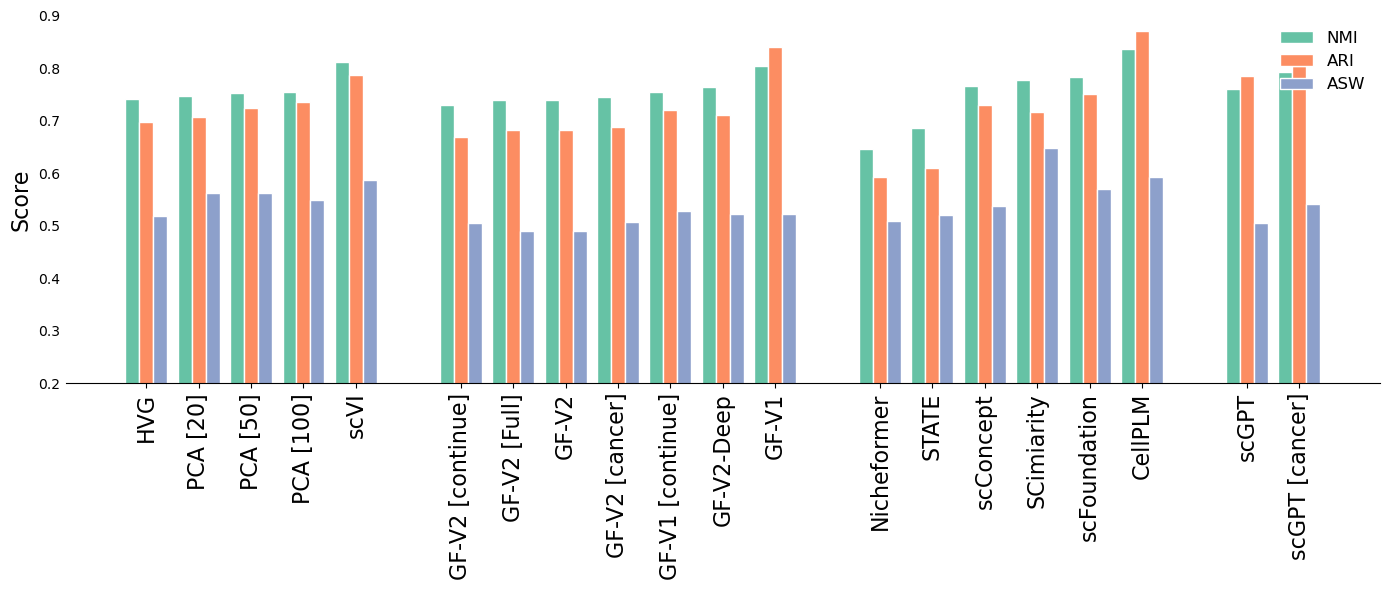

In [67]:
fig = plot_groups(results_mean_plot, cols=['NMI', 'ARI', 'ASW'])

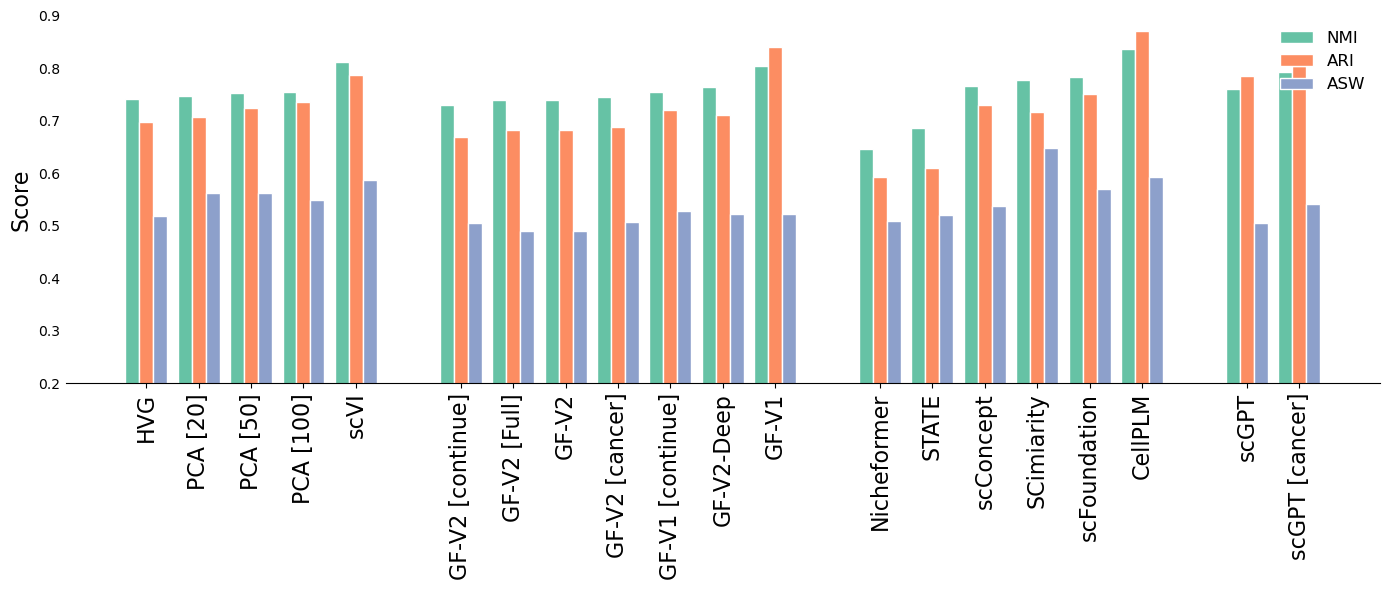

In [68]:
fig = plot_groups(results_mean_plot, cols=['NMI', 'ARI', 'ASW'])

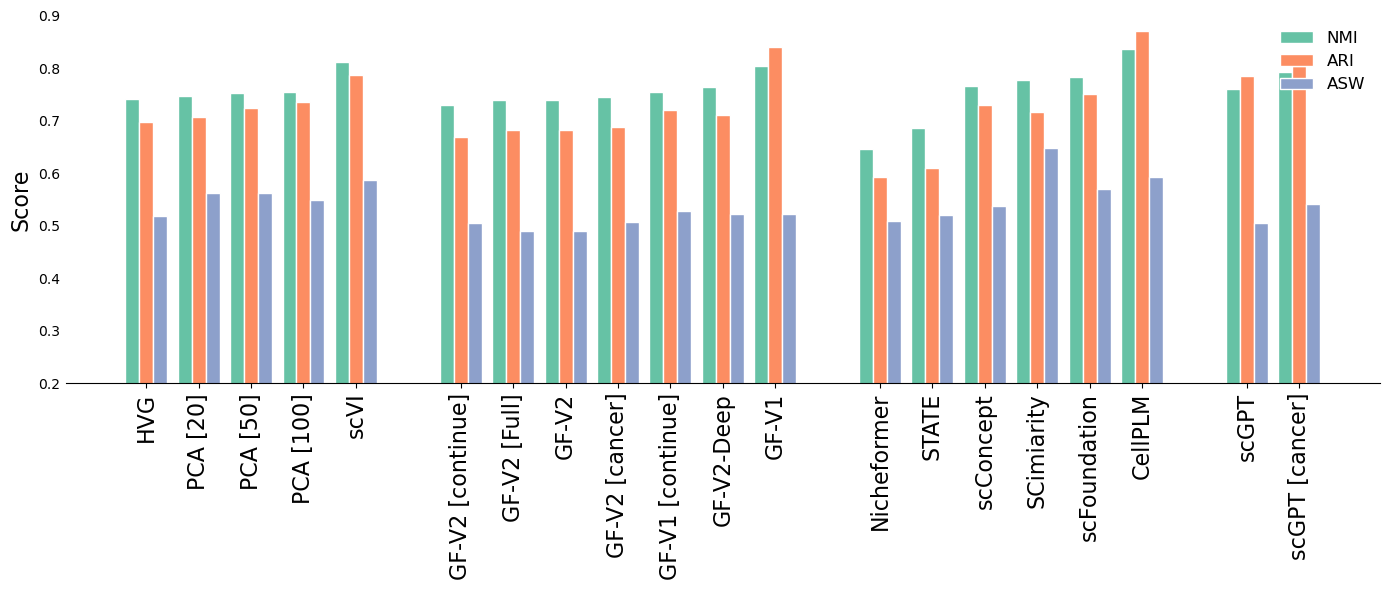

In [69]:
fig = plot_groups(results_mean_plot, cols=['NMI', 'ARI', 'ASW'])

In [70]:
fig.savefig('./plots/sub_compare_embedding_metrics.png', dpi=100)

## violinplot

In [23]:
# results_10_runs = pd.read_csv('./fig2_metrics/metrics_10_runs.csv')

In [24]:
results_10_runs

,run,model,group,leiden_resolution,n_leiden_clusters,NMI_cluster/label,ARI_cluster/label,ASW_label,graph_conn,ASW_batch,...,PCR_batch,iLISI,cLISI,kBET,avg_bio,knn_label_purity,knn_batch_purity,batch_pred_acc,kNN_label_acc,kNN_label_f1_macro
model_display,,,,,,,,,,,,,,,,,,,,,
HVG,0,hvg_seurat_4096,Baseline,0.2,14,0.739425,0.684419,0.517525,0.983183,0.475448,...,0.201333,0.027189,1.0,0.512754,0.647123,0.957867,0.415560,0.3200,0.9245,0.909779
HVG,1,hvg_seurat_4096,Baseline,0.1,10,0.765124,0.728333,0.516845,0.977675,0.476484,...,0.202841,0.026069,1.0,0.413550,0.670101,0.957400,0.414553,0.3195,0.8995,0.907264
HVG,2,hvg_seurat_4096,Baseline,0.1,9,0.734829,0.680352,0.517481,0.981039,0.476495,...,0.200860,0.028659,1.0,0.531328,0.644220,0.956827,0.413713,0.3105,0.9130,0.912007
HVG,3,hvg_seurat_4096,Baseline,0.1,10,0.732584,0.695202,0.517861,0.971821,0.474983,...,0.201534,0.027581,1.0,0.382888,0.648549,0.952220,0.410107,0.2930,0.8990,0.899312
HVG,4,hvg_seurat_4096,Baseline,0.2,12,0.748415,0.697879,0.517153,0.980973,0.473647,...,0.202307,0.029358,1.0,0.509024,0.654482,0.956993,0.413920,0.3180,0.9100,0.898508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Nicheformer,5,nicheformer_nicheformer,Other,0.5,10,0.681396,0.639256,0.508225,0.954339,0.455452,...,0.161206,0.034644,1.0,0.430374,0.609626,0.905427,0.309240,0.4030,0.9270,0.816989
Nicheformer,6,nicheformer_nicheformer,Other,0.3,7,0.641187,0.581740,0.511798,0.946483,0.456517,...,0.161133,0.034782,1.0,0.421150,0.578242,0.896727,0.310773,0.3990,0.9300,0.768839
Nicheformer,7,nicheformer_nicheformer,Other,0.3,7,0.630049,0.571631,0.508663,0.954237,0.455576,...,0.161010,0.034647,1.0,0.419086,0.570114,0.900487,0.313427,0.4100,0.9285,0.744694


In [86]:
nmi_df = results_10_runs[ ['NMI_cluster/label', 'group']].copy()
nmi_df.columns= ['NMI', 'group']

In [87]:
nmi_df= nmi_df.reset_index()

In [88]:
nmi_df['model_disp'].unique()

array(['HVG', 'STATE', 'scFoundation', 'GF-V2 [cancer]', 'GF-V2-Deep',
       'GF-V1 [continue]', 'GF-V1', 'GF-V2 [Full]', 'GF-V2 [continue]',
       'GF-V2', 'scGPT [cancer]', 'scGPT', 'CellPLM', 'SCimiarity',
       'PCA [100]', 'PCA [50]', 'PCA [20]', 'scVI', 'scConcept',
       'Nicheformer'], dtype=object)

In [89]:
# ind = nmi_df.method.str.startswith('__')
# nmi_df = nmi_df[~ind]

In [90]:
nmi_df['method'] = nmi_df['model_disp']

In [91]:
nmi_df

,model_disp,NMI,group,method
0,HVG,0.739425,Baseline,HVG
1,HVG,0.765124,Baseline,HVG
2,HVG,0.734829,Baseline,HVG
3,HVG,0.732584,Baseline,HVG
4,HVG,0.748415,Baseline,HVG
...,...,...,...,...
195,Nicheformer,0.681396,Other,Nicheformer
196,Nicheformer,0.641187,Other,Nicheformer
197,Nicheformer,0.630049,Other,Nicheformer
198,Nicheformer,0.647993,Other,Nicheformer


In [92]:
nmi_df = nmi_df[nmi_df['method'] != 'GF-V2 [continue]']

In [93]:
nmi_df

,model_disp,NMI,group,method
0,HVG,0.739425,Baseline,HVG
1,HVG,0.765124,Baseline,HVG
2,HVG,0.734829,Baseline,HVG
3,HVG,0.732584,Baseline,HVG
4,HVG,0.748415,Baseline,HVG
...,...,...,...,...
195,Nicheformer,0.681396,Other,Nicheformer
196,Nicheformer,0.641187,Other,Nicheformer
197,Nicheformer,0.630049,Other,Nicheformer
198,Nicheformer,0.647993,Other,Nicheformer


In [94]:

# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import ttest_ind
# import itertools
# import matplotlib.gridspec as gridspec
# # nmi_df = nmi_df.reset_index()
# sns.set(style="whitegrid")

# # Get unique groups and count number of methods per group
# group_method_counts = nmi_df.groupby("group")["method"].nunique()
# total_methods = group_method_counts.sum()

# # Create grid with proportional width ratios
# fig = plt.figure(figsize=(6 * len(group_method_counts)/2, 6))
# gs = gridspec.GridSpec(1, len(group_method_counts), width_ratios=group_method_counts.values, figure=fig)

# # Plot each group
# for idx, (group, method_count) in enumerate(group_method_counts.items()):
#     ax = fig.add_subplot(gs[0, idx])
#     subset = nmi_df[nmi_df['group'] == group].copy()
#     # ax.grid(False)
#     # Sort methods by mean
#     method_stats = subset.groupby("method")["NMI"].median().sort_values(ascending=True)
#     ordered_methods = method_stats.index.tolist()
#     subset["method"] = pd.Categorical(subset["method"], categories=ordered_methods, ordered=True)

#     # Violin plot
#     sns.violinplot(
#         data=subset,
#         x="method",
#         y="NMI",
#         ax=ax,
#         inner="quartile",
#         scale="area",
#         # cut=0,
#         width=0.5
#     )

#     # Add line plot for means
#     stat_values = subset.groupby("method")["NMI"].median()[ordered_methods].values
#     ax.plot(range(len(ordered_methods)), stat_values, marker='o', linestyle='--', color='black', label='Mean')

#     ax.set_title(f"{group}")
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
#     ax.set_xlabel('')
#     ax.set_ylim(0.4, .8)
#     if idx !=0 :
#         ax.set_yticklabels([])  # Hide the tick labels only, keep ticks and grid
#         ax.set_ylabel("")       # Remove the y-axis label (optional)
#         # ax.tick_params(axis='y', which='both', left=False)  # Remove tick marks

# # for i, ax in enumerate(axes):
# #     if i != 0:
# #         ax.set_yticks([])             # Remove y-axis ticks
# #         ax.set_ylabel("")             # Remove y-axis label (if any)
# #         ax.tick_params(axis='y', which='both', left=False)  # Remove tick marks
        
# # Overall title and layout
# # fig.suptitle("NMI_cluster/label Distribution by Method (Adaptive Width, Sorted, Mean Line)", fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

In [95]:
# fig.savefig('./metrics/NMI.png', dpi=100)

## Testing

In [96]:
nmi_df['method'].unique()

array(['HVG', 'STATE', 'scFoundation', 'GF-V2 [cancer]', 'GF-V2-Deep',
       'GF-V1 [continue]', 'GF-V1', 'GF-V2 [Full]', 'GF-V2',
       'scGPT [cancer]', 'scGPT', 'CellPLM', 'SCimiarity', 'PCA [100]',
       'PCA [50]', 'PCA [20]', 'scVI', 'scConcept', 'Nicheformer'],
      dtype=object)

In [100]:
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import itertools

# Load the data (adjust path as needed)
# nmi_df = pd.read_csv("nmi.csv")

# Perform all pairwise t-tests
all_methods = sorted(nmi_df['method'].unique())
pairwise_results = []

# Store group mapping for each method
method_to_group = nmi_df.drop_duplicates('method')[['method', 'group']].set_index('method')['group'].to_dict()

for m1, m2 in itertools.combinations(all_methods, 2):
    vals1 = nmi_df[nmi_df['method'] == m1]['NMI']
    vals2 = nmi_df[nmi_df['method'] == m2]['NMI']
    
    if len(vals1) > 1 and len(vals2) > 1:
        stat, pval = ttest_ind(vals1, vals2)
        mean1, mean2 = vals1.mean(), vals2.mean()
        mean_diff = mean1 - mean2
        pairwise_results.append({
            'method1': m1,
            'group1': method_to_group.get(m1, 'unknown'),
            'method2': m2,
            'group2': method_to_group.get(m2, 'unknown'),
            'mean1': mean1,
            'mean2': mean2,
            'mean_diff': mean_diff,
            'statistic': stat,
            'raw_p': pval
        })

# Convert to DataFrame
pairwise_df = pd.DataFrame(pairwise_results)

# Apply FDR correction
_, corrected_pvals, _, _ = multipletests(pairwise_df['raw_p'], method='fdr_bh')
pairwise_df['FDR_adj_p'] = corrected_pvals
pairwise_df['significant'] = pairwise_df['FDR_adj_p'] < 0.05
pairwise_df['direction'] = pairwise_df['mean_diff'].apply(lambda x: '>' if x > 0 else '<')

# Organize columns
pairwise_df = pairwise_df[[
    'group1', 'method1', 'group2', 'method2',
    'mean1', 'mean2', 'direction', 'mean_diff',
    'statistic', 'raw_p', 'FDR_adj_p', 'significant'
]]

# Optional: sort for readability
pairwise_df.sort_values(by=['group1', 'method1', 'group2', 'method2'], inplace=True)

# Display table
print(pairwise_df.to_string(index=False))

    group1          method1     group2          method2    mean1    mean2 direction  mean_diff  statistic        raw_p    FDR_adj_p  significant
  Baseline              HVG   Baseline        PCA [100] 0.740106 0.754905         <  -0.014800  -2.027611 5.766844e-02 7.826431e-02        False
  Baseline              HVG   Baseline         PCA [20] 0.740106 0.747609         <  -0.007503  -1.047880 3.085612e-01 3.517598e-01        False
  Baseline              HVG   Baseline         PCA [50] 0.740106 0.751573         <  -0.011467  -1.808549 8.725767e-02 1.147774e-01        False
  Baseline              HVG   Baseline             scVI 0.740106 0.811561         <  -0.071456  -9.336120 2.542940e-08 1.035340e-07         True
  Baseline              HVG      Other      Nicheformer 0.740106 0.645637         >   0.094469  13.964460 4.240197e-11 3.587911e-10         True
  Baseline              HVG      Other       SCimiarity 0.740106 0.776948         <  -0.036842  -4.453965 3.066222e-04 5.825821e-0

In [101]:
pairwise_df = pairwise_df.round(3)

In [102]:
pairwise_df.to_csv('./fig2_metrics/stats_test.csv')

In [103]:
# n = len(ordered_methods)
# pairs= []
# for i in range(n):
#     for j in range(i + 1, n):
#         pairs.append((ordered_methods[i], ordered_methods[j]))

In [104]:
nmi_df

,model_disp,NMI,group,method
0,HVG,0.739425,Baseline,HVG
1,HVG,0.765124,Baseline,HVG
2,HVG,0.734829,Baseline,HVG
3,HVG,0.732584,Baseline,HVG
4,HVG,0.748415,Baseline,HVG
...,...,...,...,...
195,Nicheformer,0.681396,Other,Nicheformer
196,Nicheformer,0.641187,Other,Nicheformer
197,Nicheformer,0.630049,Other,Nicheformer
198,Nicheformer,0.647993,Other,Nicheformer


CellPLM scVI
CellPLM GF-V1
CellPLM scGPT [cancer]
CellPLM scFoundation
CellPLM SCimiarity
CellPLM scConcept
CellPLM GF-V2-Deep
CellPLM scGPT
CellPLM PCA [100]
CellPLM GF-V1 [continue]
CellPLM PCA [50]
CellPLM PCA [20]
CellPLM GF-V2 [cancer]
CellPLM HVG
CellPLM GF-V2 [Full]
CellPLM GF-V2
CellPLM STATE
CellPLM Nicheformer
scVI CellPLM
scVI GF-V1
scVI scGPT [cancer]
scVI scFoundation
scVI SCimiarity
scVI scConcept
scVI GF-V2-Deep
scVI scGPT
scVI PCA [100]
scVI GF-V1 [continue]
scVI PCA [50]
scVI PCA [20]
scVI GF-V2 [cancer]
scVI HVG
scVI GF-V2 [Full]
scVI GF-V2
scVI STATE
scVI Nicheformer
GF-V1 CellPLM
GF-V1 scVI
GF-V1 scGPT [cancer]
GF-V1 scFoundation
GF-V1 SCimiarity
GF-V1 scConcept
GF-V1 GF-V2-Deep
GF-V1 scGPT
GF-V1 PCA [100]
GF-V1 GF-V1 [continue]
GF-V1 PCA [50]
GF-V1 PCA [20]
GF-V1 GF-V2 [cancer]
GF-V1 HVG
GF-V1 GF-V2 [Full]
GF-V1 GF-V2
GF-V1 STATE
GF-V1 Nicheformer
scGPT [cancer] CellPLM
scGPT [cancer] scVI
scGPT [cancer] GF-V1
scGPT [cancer] scFoundation
scGPT [cancer] SCimiarity
s

/tmp/ipykernel_1791/4260098343.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


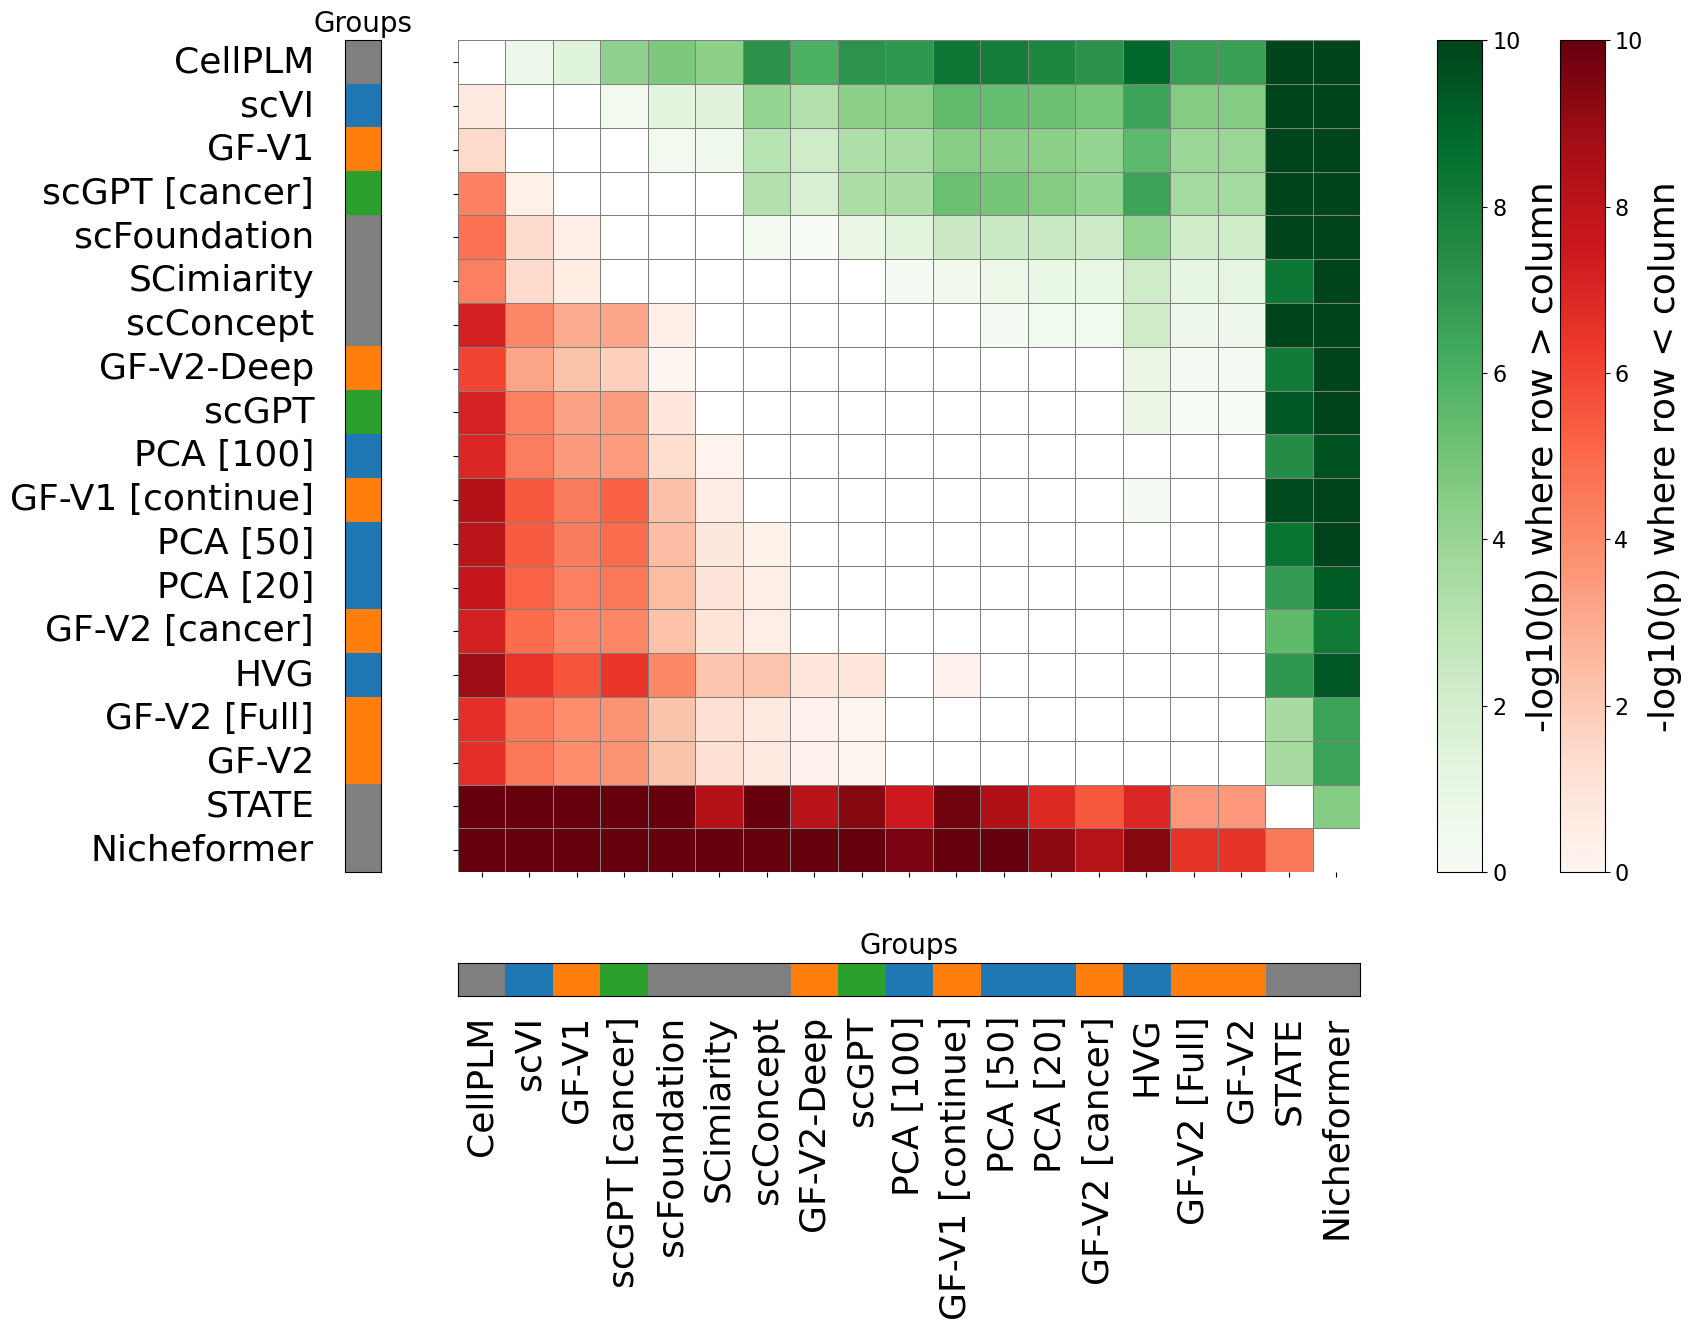

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import itertools



group_colors = {
    'Baseline': '#1f77b4',
    'Geneformer': '#ff7f0e',
    'scGPT': '#2ca02c',
    'other': '#7f7f7f',
    'Other': '#7f7f7f'
}

def get_pairwise_tests(nmi_df, ordered_methods):
    pairwise_results = []
    
    for m1, m2 in itertools.permutations(ordered_methods, 2):
    # for m1, m2 in pairs:
        print(m1, m2)
        vals1 = nmi_df[nmi_df['method'] == m1]['NMI']
        vals2 = nmi_df[nmi_df['method'] == m2]['NMI']
        if len(vals1) > 1 and len(vals2) > 1:
            stat, pval = ttest_ind(vals1, vals2)
            mean_diff = vals1.mean() - vals2.mean()
            pairwise_results.append({
                'method1': m1, 'method2': m2,
                'mean_diff': mean_diff, 'p_value': pval
            })

    pairwise_df = pd.DataFrame(pairwise_results)
    _, corrected_pvals, _, _ = multipletests(pairwise_df['p_value'], method='fdr_bh')
    pairwise_df['FDR_adj_p'] = corrected_pvals
    pairwise_df['significant'] = pairwise_df['FDR_adj_p'] < 0.05
    pairwise_df['direction'] = pairwise_df['mean_diff'].apply(lambda x: '>' if x > 0 else '<')
    return pairwise_df


method_nmi_means = nmi_df.groupby('method')['NMI'].mean()
method_group_df = pd.DataFrame({
    'method': method_nmi_means.index,
    'group': [map_groups(m) for m in method_nmi_means.index],
    'mean_nmi': method_nmi_means.values
})
# method_group_df['group'] = pd.Categorical(method_group_df['group'], categories=['Baseline', 'Geneformer', 'scGPT', 'Other'], ordered=True)
# method_group_df = method_group_df.sort_values(by=['group', 'mean_nmi'], ascending=[True, False])
method_group_df = method_group_df.sort_values(by=['mean_nmi'], ascending=[False])

ordered_methods = method_group_df['method'].tolist()

pairwise_df=  get_pairwise_tests(nmi_df, ordered_methods)

# === STEP 4: Build directional matrices ===
log_pval_pos = pd.DataFrame(np.nan, index=ordered_methods, columns=ordered_methods)
log_pval_neg = pd.DataFrame(np.nan, index=ordered_methods, columns=ordered_methods)
log_pval = pd.DataFrame(np.nan, index=ordered_methods, columns=ordered_methods)


for i, row in pairwise_df.iterrows():
    if row['significant']:
        val = -np.log10(row['FDR_adj_p'])
        log_pval.loc[row['method1'], row['method2']] = val
        print(row['direction'])
        if row['direction'] == '>':
            log_pval_pos.loc[row['method1'], row['method2']] = val
        else:
            log_pval_neg.loc[row['method1'], row['method2']] = val
        

log_pval_pos = log_pval_pos.clip(upper=10)
log_pval_neg = log_pval_neg.clip(upper=10)

# Flip x-axis
# reversed_methods = ordered_methods[::-1]
reversed_methods = ordered_methods


# Get group color bars
rgb_colors_y = np.array([to_rgb(group_colors[map_groups(m)]) for m in ordered_methods])
rgb_colors_x = np.array([to_rgb(group_colors[map_groups(m)]) for m in reversed_methods])

# === STEP 5: Final plot ===
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(3, 4, width_ratios=(0.4, 10, 0.5, 0.5), height_ratios=(0.5, 10, 0.4),
                      wspace=0.3, hspace=0.3)

# Main heatmap axis
ax_main = fig.add_subplot(gs[1, 1])


sns.heatmap(log_pval_pos, cmap="Greens", cbar=False,
            ax=ax_main, linewidths=0.5, linecolor='gray')

sns.heatmap(log_pval_neg, cmap="Reds", 
            cbar=False, ax=ax_main, linewidths=0.5, linecolor='gray')


# sns.heatmap(log_pval, cmap="Reds", 
#             cbar=False, ax=ax_main, linewidths=0.5, linecolor='gray')

ax_main.grid(False)


ax_main.set_xticklabels(ax_main.get_xticklabels(), rotation=90, fontsize=26)
ax_main.set_yticklabels(ax_main.get_yticklabels(), rotation=0, fontsize=26)
ax_main.tick_params(axis='x', pad=100)
ax_main.tick_params(axis='y', pad=100)

# Y group panel
ax_group_y = fig.add_subplot(gs[1, 0])
ax_group_y.imshow(rgb_colors_y.reshape(-1, 1, 3), aspect='auto')
ax_group_y.set_xticks([])
ax_group_y.set_yticks([])
ax_group_y.set_title("Groups", fontsize=20)

# X group panel
ax_group_x = fig.add_subplot(gs[2, 1])
ax_group_x.imshow(rgb_colors_x.reshape(1, -1, 3), aspect='auto')
ax_group_x.set_xticks([])
ax_group_x.set_yticks([])
ax_group_x.set_title("Groups", fontsize=20)

# Colorbars
norm = plt.Normalize(vmin=0, vmax=10)

ax_cbar_pos = fig.add_subplot(gs[1, 2])
sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)
sm.set_array([])
cbar_pos = fig.colorbar(sm, cax=ax_cbar_pos)
cbar_pos.set_label("-log10(p) where row > column", fontsize=26)  # Label font size
cbar_pos.ax.tick_params(labelsize=16)

# fig.colorbar(sm, cax=ax_cbar_pos)

ax_cbar_neg = fig.add_subplot(gs[1, 3])
sm2 = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
sm2.set_array([])
cbar_neg = fig.colorbar(sm2, cax=ax_cbar_neg)

cbar_neg.set_label("-log10(p) where row < column", fontsize=26)  # Label font size
cbar_neg.ax.tick_params(labelsize=16)

# fig.colorbar(sm2, cax=ax_cbar_neg)

plt.tight_layout()
fig.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.22) # Adjust margins

plt.show()
fig.savefig('plots/nmi_stat_testing.png', dpi=100)


#### log_pval_neg_flipped

In [106]:
log_pval_pos_flipped

NameError: name 'log_pval_pos_flipped' is not defined

In [ ]:
pivot_df = pairwise_df.pivot_table(index='method1', columns='method2', values='FDR_adj_p', aggfunc='first')
pivot_df

In [ ]:
ordered_methods

In [ ]:
pivot_df.sort_index(ordered_methods)

In [ ]:
pivot_df[ordered_methods]

In [ ]:
method_group_df

In [ ]:
# Ensure each pair is ordered so that all comparisons fall in the upper triangle
df[['method1', 'method2']] = df[['method1', 'method2']].apply(sorted, axis=1, result_type='expand')

# Get all unique methods
all_methods = pd.unique(df[['method1', 'method2']].values.ravel('K'))
all_methods = sorted(all_methods)

# Initialize matrices
heatmap_data = pd.DataFrame(index=all_methods, columns=all_methods, dtype=float)
direction_data = pd.DataFrame(index=all_methods, columns=all_methods, dtype=object)

# Populate matrices with -log10(p-value) and direction symbol
for _, row in df.iterrows():
    method1 = row['method1']
    method2 = row['method2']
    pval = row['FDR_adj_p']
    direction = row['direction']

    value = -np.log10(pval) if pval > 0 else 50
    heatmap_data.loc[method1, method2] = value
    direction_data.loc[method1, method2] = direction

# Plot
plt.figure(figsize=(12, 10))
sns.set(style="white")

ax = sns.heatmap(
    heatmap_data,
    cmap="Blues",
    cbar_kws={'label': '-log10(FDR_adj_p)'},
    linewidths=0.5,
    linecolor='gray',
    square=True,
    mask=heatmap_data.isnull()
)

# Annotate direction (< or >)
for i in range(len(all_methods)):
    for j in range(len(all_methods)):
        dir_symbol = direction_data.iloc[i, j]
        if pd.notnull(dir_symbol):
            ax.text(j + 0.5, i + 0.5, dir_symbol, ha='center', va='center', fontsize=8, color='black')

# Format axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title('Upper-Triangle Pairwise Test (-log10 p-value) with Direction')
plt.tight_layout()
plt.show()